In [58]:
import numpy as np
import pandas as pd

from pymatgen.core import Structure
import matgl
from matgl.ext.pymatgen import Structure2Graph

In [59]:
path = "../FinalProjectSlam/graph/3DSC/superconductors_3D/data/final/MP"
path_red = "../FinalProjectSlam/graph/3DSC/superconductors_3D"

In [60]:
data = pd.read_csv(path + "/3DSC_MP.csv", skiprows=1)
#print(data.columns)
print(data.loc[0,'tc'])
print(data.loc[0,'cif'])

2.64
data/final/MP/cifs/Ag0.02Ge2Pd1.98Sr1-MP-mp-978986-synth_doped.cif


In [61]:

structure = Structure.from_file(path_red +'/'+ data.loc[0,'cif'])
structure

Structure Summary
Lattice
    abc : 4.438672 4.438672 6.03054834
 angles : 111.59328752 111.59328752 89.99999998999999
 volume : 101.4530475362769
      A : 4.127164255059669 0.0 -1.6335006383046717
      B : -0.6465272925912613 4.076209912182743 -1.6335006383046717
      C : 0.0 0.0 6.03054834
    pbc : True True True
PeriodicSite: Sr0 (Sr) (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]
PeriodicSite: Ge1 (Ge) (1.29, 1.511, 3.259) [0.3706, 0.3706, 0.7411]
PeriodicSite: Ge1 (Ge) (2.191, 2.566, -0.4953) [0.6294, 0.6294, 0.2589]
PeriodicSite: Ag3 (Ag:0.01, Pd:0.99) (0.5469, 3.057, 1.382) [0.25, 0.75, 0.5]
PeriodicSite: Ag3 (Ag:0.01, Pd:0.99) (2.934, 1.019, 1.382) [0.75, 0.25, 0.5]

In [ ]:
# import numpy as np
# import torch
# from torch_geometric.data import Data
# from pymatgen.core import Structure

# # Gaussian basis expansion for bond distances (like CGCNN)
# def gaussian_expansion(distances, dmin=0, dmax=8, steps=40):
#     filters = np.linspace(dmin, dmax, steps)
#     sigma = (dmax - dmin) / steps
#     return np.exp(-((distances[:, None] - filters[None, :]) ** 2) / sigma ** 2)

# def get_atom_features(structure):
#     features = []
#     for site in structure:
        
#         if site.is_ordered:
#             elem = site.specie
#             features.append([
#                 float(elem.Z),
#                 float(elem.atomic_mass),
#                 float(elem.atomic_radius) if elem.atomic_radius else 0.0,
#                 float(elem.X) if elem.X else 0.0,          # electronegativity
#                 float(elem.row),                            # period in periodic table
#                 float(elem.group),                         # group in periodic table
#                 1.0,                                        # occupancy (fully occupied)
#                 0.0,                                        # disorder: 0 = pure site
#             ])
#         else:
#             Z, mass, radius, X, row, group = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
#             # measure of disorder (like entropy)
#             occupancies = list(site.species.values())
#             disorder = -sum(o * np.log(o + 1e-9) for o in occupancies)
            
#             for elem, occ in site.species.items():
#                 Z      += occ * float(elem.Z)
#                 mass   += occ * float(elem.atomic_mass)
#                 radius += occ * (float(elem.atomic_radius) if elem.atomic_radius else 0.0)
#                 X      += occ * (float(elem.X) if elem.X else 0.0)
#                 row    += occ * float(elem.row)
#                 group  += occ * float(elem.group)

#             features.append([Z, mass, radius, X, row, group,
#                               max(occupancies),  # dominant occupancy
#                               disorder])         # site disorder

#     return np.array(features, dtype=np.float32)

# def structure_to_graph(structure, target, cutoff=8.0, cutoff_neigh=4):
#     # Node features
#     atom_feats = get_atom_features(structure)
#     x = torch.tensor(atom_feats, dtype=torch.float)

#     # Find neighbors within cutoff
#     all_neighbors = structure.get_all_neighbors(cutoff, include_index=True)

#     edge_src, edge_dst, edge_distances = [], [], []
#     for i, neighbors in enumerate(all_neighbors):
#         for neighbor in neighbors:
#             # distance = neighbor[1]
#             # if distance <= cutoff_neigh:  # Explicit filter
#             edge_src.append(i)
#             edge_dst.append(neighbor[2])       # index of neighbor atom
#             edge_distances.append(neighbor[1]) # distance

#     edge_index = torch.tensor(np.array([edge_src, edge_dst]), dtype=torch.long)

#     # Edge features: Gaussian expanded distances
#     distances = np.array(edge_distances)
#     edge_attr = torch.tensor(gaussian_expansion(distances), dtype=torch.float)
#     #print(distances, edge_attr)
#     # Target value
#     y = torch.tensor([target], dtype=torch.float)
#     data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
#     return data


# structure = Structure.from_file(path_red +'/' + data.loc[0,'cif'])
# graph = structure_to_graph(structure, target=2.64, cutoff=8.0, cutoff_neigh=4)
# print(structure.get_all_neighbors(8, include_index=True))

[[PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-0.5469, -3.057, -1.382) [-0.25, -0.75, -0.5], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-2.934, -1.019, -1.382) [-0.75, -0.25, -0.5], PeriodicNeighbor: Ge1 (Ge) (-1.29, -1.511, -3.259) [-0.3706, -0.3706, -0.7411], PeriodicNeighbor: Sr0 (Sr) (-3.481, -4.076, -2.764) [-1.0, -1.0, -1.0], PeriodicNeighbor: Ge1 (Ge) (-2.191, -2.566, -5.535) [-0.6294, -0.6294, -1.259], PeriodicNeighbor: Ge1 (Ge) (-0.6433, -5.587, -1.625) [-0.3706, -1.371, -0.7411], PeriodicNeighbor: Ge1 (Ge) (-1.544, -6.642, -3.902) [-0.6294, -1.629, -1.259], PeriodicNeighbor: Ge1 (Ge) (-5.417, -1.511, -1.625) [-1.371, -0.3706, -0.7411], PeriodicNeighbor: Ge1 (Ge) (-6.318, -2.566, -3.902) [-1.629, -0.6294, -1.259], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-0.5469, -3.057, 4.649) [-0.25, -0.75, 0.5], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-2.934, -1.019, 4.649) [-0.75, -0.25, 0.5], PeriodicNeighbor: Ge1 (Ge) (-1.29, -1.511, 2.772) [-0.3706, -0.3706, 0.2589], PeriodicNeighbor: G

In [111]:
import numpy as np
import torch
from torch_geometric.data import Data
from pymatgen.core import Structure

# matminer featurizers — load once, apply fast (no per-atom API calls)
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.site import CrystalNNFingerprint
from matminer.featurizers.structure import SineCoulombMatrix
from pymatgen.core import Composition

# ── Build featurizers once at module level ────────────────────────────────────
# ElementProperty uses a local property table (Magpie, etc.) — no network I/O.
# "magpie" gives you ~130 features: electronegativity, atomic radius, row,
# group, valence electrons, melting point, cohesive energy, …
elem_feat = ElementProperty.from_preset("magpie")

# CrystalNNFingerprint captures local coordination environment per site
# (CN, bond angles, polyhedron type). Better than raw Z + group.
site_feat = CrystalNNFingerprint.from_preset("ops")

# ── Gaussian basis (unchanged) ────────────────────────────────────────────────
def gaussian_expansion(distances, dmin=0, dmax=8, steps=40):
    filters = np.linspace(dmin, dmax, steps)
    sigma = (dmax - dmin) / steps
    return np.exp(-((distances[:, None] - filters[None, :]) ** 2) / sigma**2)


# ── Node features ─────────────────────────────────────────────────────────────
def get_atom_features(structure: Structure) -> np.ndarray:
    """
    Per-atom features = Magpie element statistics (stats over a
    single-element composition) + CrystalNN coordination fingerprint.

    ElementProperty.featurize() expects a Composition, so we pass
    a single-element one for each site's dominant species.
    """
    elem_vectors, site_vectors = [], []

    for i, site in enumerate(structure):
        # --- element features (from local table, ~130 values) ---
        if site.is_ordered:
            comp = site.specie.symbol  # e.g. "Fe"
        else:
            # pick dominant species for element stats
            comp = max(site.species, key=site.species.get).symbol

        ev = elem_feat.featurize(Composition(comp))
        elem_vectors.append(ev)

        # --- site / coordination features (~61 values for "ops" preset) ---
        try:
            sv = site_feat.featurize(structure, i)
        except Exception:
            # CrystalNN can fail on highly disordered / unusual sites
            sv = [0.0] * len(site_feat.feature_labels())
        site_vectors.append(sv)

    elem_arr = np.array(elem_vectors, dtype=np.float32)
    site_arr = np.array(site_vectors, dtype=np.float32)

    # Replace NaN/inf that occasionally appear in Magpie features
    elem_arr = np.nan_to_num(elem_arr, nan=0.0, posinf=0.0, neginf=0.0)
    site_arr = np.nan_to_num(site_arr, nan=0.0, posinf=0.0, neginf=0.0)

    return np.hstack([elem_arr, site_arr])   # shape: (N_atoms, ~191)


# ── Graph construction ────────────────────────────────────────────────────────
def structure_to_graph(structure: Structure, target: float,
                       cutoff: float = 8.0) -> Data:
    atom_feats = get_atom_features(structure)
    x = torch.tensor(atom_feats, dtype=torch.float)

    all_neighbors = structure.get_all_neighbors(cutoff, include_index=True)
    edge_src, edge_dst, edge_distances = [], [], []

    for i, neighbors in enumerate(all_neighbors):
        for nbr in neighbors:
            edge_src.append(i)
            edge_dst.append(nbr[2])
            edge_distances.append(nbr[1])

    edge_index = torch.tensor(
        np.array([edge_src, edge_dst]), dtype=torch.long
    )

    distances = np.array(edge_distances, dtype=np.float32)
    # Gaussian basis gives 40-dim bond fingerprint (same as CGCNN)
    edge_attr = torch.tensor(gaussian_expansion(distances), dtype=torch.float)

    y = torch.tensor([target], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [112]:
cut_off = 8
structure = Structure.from_file(path_red +'/' + data.loc[0,'cif'])
graph = structure_to_graph(structure, target=2.64, cutoff=8.0)
graph

Data(x=[5, 193], edge_index=[2, 480], edge_attr=[480, 40], y=[1])

In [ ]:
from pymatgen.core import Structure

graphs = []
for i, row in data.iterrows():
    try:
        structure = Structure.from_file(path_red + '/' + row['cif'])
        #print(structure)
        graph = structure_to_graph(structure, target=row['tc'], cutoff=8)
        graphs.append(graph)
    except Exception as e:
        print(f"Skipping row {i}: {e}")

from sklearn.preprocessing import StandardScaler
import torch

# Collect all node features
all_x = torch.cat([g.x for g in graphs], dim=0).numpy()
scaler = StandardScaler()
scaler.fit(all_x)

for g in graphs:
    g.x = torch.tensor(scaler.transform(g.x.numpy()), dtype=torch.float)

filtered_data = [data for data in graphs if data.y.item() != 0]
tc_values = np.array([g.y.item() for g in filtered_data])
tc_mean, tc_std = tc_values.mean(), tc_values.std()

for g in graphs:
    g.y = (g.y - tc_mean) / tc_std
    

print(f"Built {len(graphs)} graphs")
print(graphs[0])  # inspect first graph
graphs = torch.save(graphs,'crystal_graphs.pt')

/Users/amaliedavidsen/Documents/uni_MSc/AML/AppliedML2026/.conda/lib/python3.11/site-packages/pymatgen/core/local_env.py:4045: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
/Users/amaliedavidsen/Documents/uni_MSc/AML/AppliedML2026/.conda/lib/python3.11/site-packages/pymatgen/core/local_env.py:4047: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
/Users/amaliedavidsen/Documents/uni_MSc/AML/AppliedML2026/.conda/lib/python3.11/site-packages/matminer/featurizers/site/fingerprint.py:454: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nndata = self.cnn.get_nn_data(struct, idx)
/Users/amaliedavidsen/Documents/uni_MSc/AML/AppliedML2026/.conda/lib/python3.11/site-packages/pymatgen/core/struct

Built 5773 graphs
Data(x=[5, 193], edge_index=[2, 480], edge_attr=[480, 40], y=[1])


In [65]:
graphs = torch.load('crystal_graphs.pt', weights_only=False)
print(graphs[10])  # inspect first graph

Data(x=[6, 8], edge_index=[2, 188], edge_attr=[188, 40], y=[1])


In [ ]:
import numpy as np
import torch
from torch_geometric.data import Data
from pymatgen.core import Structure

# matminer featurizers — load once, apply fast (no per-atom API calls)
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.site import CrystalNNFingerprint
from matminer.featurizers.structure import SineCoulombMatrix
from pymatgen.core import Composition

# ── Build featurizers once at module level ────────────────────────────────────
# ElementProperty uses a local property table (Magpie, etc.) — no network I/O.
# "magpie" gives you ~130 features: electronegativity, atomic radius, row,
# group, valence electrons, melting point, cohesive energy, …
elem_feat = ElementProperty.from_preset("magpie")

# CrystalNNFingerprint captures local coordination environment per site
# (CN, bond angles, polyhedron type). Better than raw Z + group.
site_feat = CrystalNNFingerprint.from_preset("ops")

# ── Gaussian basis (unchanged) ────────────────────────────────────────────────
def gaussian_expansion(distances, dmin=0, dmax=8, steps=40):
    filters = np.linspace(dmin, dmax, steps)
    sigma = (dmax - dmin) / steps
    return np.exp(-((distances[:, None] - filters[None, :]) ** 2) / sigma**2)


# ── Node features ─────────────────────────────────────────────────────────────
def get_atom_features(structure: Structure) -> np.ndarray:
    """
    Per-atom features = Magpie element statistics (stats over a
    single-element composition) + CrystalNN coordination fingerprint.

    ElementProperty.featurize() expects a Composition, so we pass
    a single-element one for each site's dominant species.
    """
    elem_vectors, site_vectors = [], []

    for i, site in enumerate(structure):
        # --- element features (from local table, ~130 values) ---
        if site.is_ordered:
            comp = site.specie.element.symbol  # e.g. "Fe"
        else:
            # pick dominant species for element stats
            comp = max(site.species, key=site.species.get).symbol

        ev = elem_feat.featurize(Composition(comp))
        elem_vectors.append(ev)

        # --- site / coordination features (~61 values for "ops" preset) ---
        try:
            sv = site_feat.featurize(structure, i)
        except Exception:
            # CrystalNN can fail on highly disordered / unusual sites
            sv = [0.0] * len(site_feat.feature_labels())
        site_vectors.append(sv)

    elem_arr = np.array(elem_vectors, dtype=np.float32)
    site_arr = np.array(site_vectors, dtype=np.float32)

    # Replace NaN/inf that occasionally appear in Magpie features
    elem_arr = np.nan_to_num(elem_arr, nan=0.0, posinf=0.0, neginf=0.0)
    site_arr = np.nan_to_num(site_arr, nan=0.0, posinf=0.0, neginf=0.0)

    return np.hstack([elem_arr, site_arr])   # shape: (N_atoms, ~191)


# ── Graph construction ────────────────────────────────────────────────────────
def structure_to_graph(structure: Structure, target: float,
                       cutoff: float = 8.0) -> Data:
    atom_feats = get_atom_features(structure)
    x = torch.tensor(atom_feats, dtype=torch.float)

    all_neighbors = structure.get_all_neighbors(cutoff, include_index=True)
    edge_src, edge_dst, edge_distances = [], [], []

    for i, neighbors in enumerate(all_neighbors):
        for nbr in neighbors:
            edge_src.append(i)
            edge_dst.append(nbr[2])
            edge_distances.append(nbr[1])

    edge_index = torch.tensor(
        np.array([edge_src, edge_dst]), dtype=torch.long
    )

    distances = np.array(edge_distances, dtype=np.float32)
    # Gaussian basis gives 40-dim bond fingerprint (same as CGCNN)
    edge_attr = torch.tensor(gaussian_expansion(distances), dtype=torch.float)

    y = torch.tensor([target], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

Full Formula (Pr2 Fe2 As2 O1.78 F0.22)
Reduced Formula: Pr2Fe2As2O1.78F0.22
abc   :   4.094889   4.094889   9.258722
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (8)
  #  SP                a    b         c
---  --------------  ---  ---  --------
  0  Pr              0    0.5  0.871431
  1  Pr              0.5  0    0.128569
  2  Fe              0    0    0.5
  3  Fe              0.5  0.5  0.5
  4  As              0    0.5  0.323417
  5  As              0.5  0    0.676583
  6  O:0.89, F:0.11  0    0    0
  7  O:0.89, F:0.11  0.5  0.5  0 data/final/MP/cifs/As1F0.11Fe1Pr1O0.89-MP-mp-22491-synth_doped.cif


/var/folders/qf/1p_ffz6j5ljc117p2xzz4gsm0000gn/T/ipykernel_9142/1556959492.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


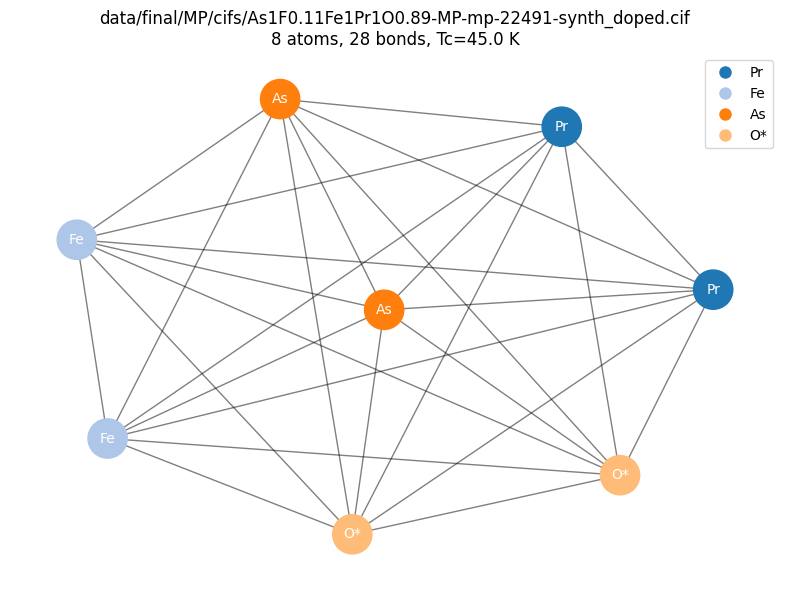

In [89]:
i = 500
structure = Structure.from_file(path_red + '/' + data.loc[i, 'cif'])
print(structure,data.loc[i, 'cif'])
graph = structure_to_graph(structure, target=data.loc[i, 'tc'])
draw_crystal_graph(graph, structure, title=data.loc[i, 'cif'])

## Run google colab notebook here

In [128]:
model = torch.load('cgcnn_data/cgcnn_model_matminer_features.pt', weights_only=False, map_location=torch.device('mps'))
loss = np.loadtxt('cgcnn_data/cgcnn_loss_hist_matminer_features.csv')
y_pred = np.loadtxt('cgcnn_data/cgcnn_pred_matminer_features.csv') * tc_std + tc_mean #renormalize
y_true = np.loadtxt('cgcnn_data/cgcnn_targets_matminer_features.csv') * tc_std + tc_mean

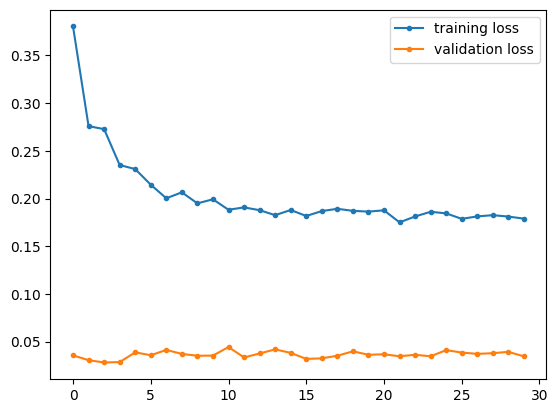

In [129]:
import matplotlib.pyplot as plt

plt.plot(loss[:,0], '.-', label = 'training loss')
plt.plot(loss[:,1], '.-', label = 'validation loss')
#plt.yscale('log')
plt.legend()

In [130]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R² Score: {r2:.6f}")

MSE: 86.875248
MAE: 3.590438
R² Score: -4.230660


np.float64(2864334.829487405)

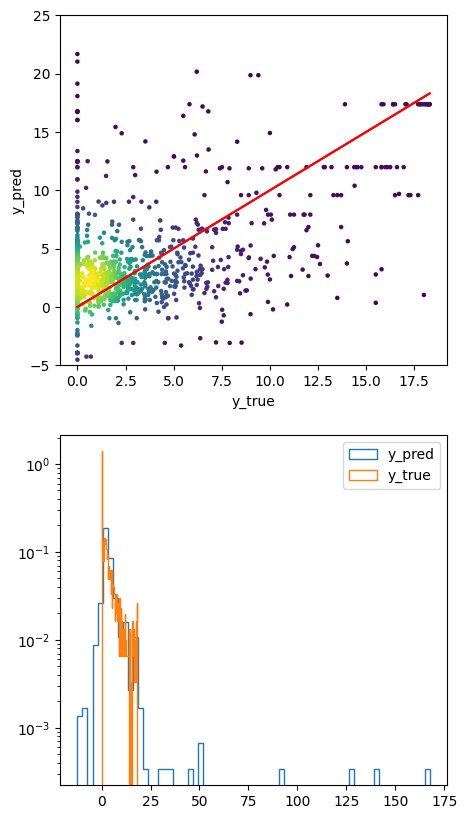

In [141]:
from scipy.stats import gaussian_kde

x = np.linspace(0,np.max(y_true),100)
y = x

# Calculate the point density
xy = np.vstack([y_true.reshape(-1),y_pred.reshape(-1)])
z = gaussian_kde(xy)(xy)


fig, axs = plt.subplots(2, figsize = (5,10))
axs[0].scatter(y_true,y_pred, c=z, s=5)
axs[0].plot(x, y, '-r')
#axs[0].set_xscale('log')
#axs[0].set_yscale('log')
axs[0].plot(x, y, '-r')
axs[0].set_xlabel('y_true')
axs[0].set_ylabel('y_pred')
axs[0].set_ylim(-5,25)
axs[1].hist(y_pred, alpha=1 ,histtype='step', density=True, bins=70, label='y_pred')
axs[1].hist(y_true,alpha=1 ,histtype='step', density=True, bins=70, label='y_true')
axs[1].set_yscale('log')
axs[1].legend()


relmad = (y_pred - y_true)/y_true
np.mean(abs(relmad[np.where(y_true != 0)]))

(array([2.05468988, 2.70000005]), array([2.35072327, 1.29999995]))